In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from run_evolution import folder_evol
from sklearn.decomposition import PCA
from analytical_results import fT00, fT01, fT11, fj0, fj1, fnu, fLn
from ploting import plot_heatmaps
save = False

In [4]:
g = 1
v = 1
Q = 1
dt = 1 / 16
tol = 1e-6
method = '12site'
snapshots_states = 16
mlat = True

data = {}
ms = [0.0, 0.1, 0.2, 0.3183, 0.4, 0.5, 0.6, 0.7]
for m in ms:
    for (N, a) in [(512, 1/8), (1024, 1 / 16)]:
        for D in [128, 256]:
            folder = folder_evol(g, m, a, N, v, Q, D, dt, D, tol, method, mlat, mkdir=False)
            try:
                d = np.load(folder / f"results.npy", allow_pickle=True).item()
                data[m, N, a, D] = d
            except FileNotFoundError:
                pass

# labels for projections on 1 and 2 bonds
E1s = np.array([-3, -2, -1, 0, 1, 2, 3]) - 1  # -1 to take into account left-moving charge
E2s = np.array([-6, -5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5, 6]) / 2 - 1  # -1 to take into account left-moving charge

In [55]:
# calculated quantities
for x in sorted(d.keys()):
    print(x)

Ln
T00
T01
T11
energy
ent1a
ent1b
ent1c
entropy_1
entropy_2
entropy_3
evol_time
j0
j1
min_Schmidt
nu
pr1a
pr1b
pr1c
pr2
time


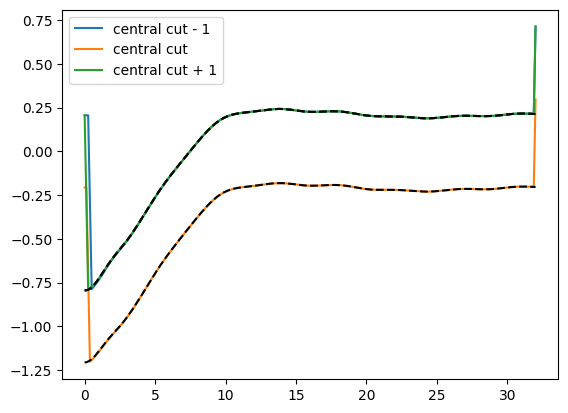

In [ ]:
# testing 2 ways of valvulating expectation value
# d['Ln'] directly includes external charge,
# which is why there is a jump when it starts and left the system

m, N, a, D = 0.5, 512, 0.125, 256
d = data[m, N, a, D]
plt.plot(d['time'], d['Ln'][:, N // 2 + 2], label='central cut - 1');
plt.plot(d['time'], d['pr1c'] @ E1s, '--k');

plt.plot(d['time'],  d['Ln'][:, N // 2 + 1], label='central cut');
plt.plot(d['time'], d['pr1b'] @ E1s, '--k');

plt.plot(d['time'],  d['Ln'][:, N // 2], label='central cut + 1');
plt.plot(d['time'], d['pr1a'] @ E1s, '--k');

plt.legend()

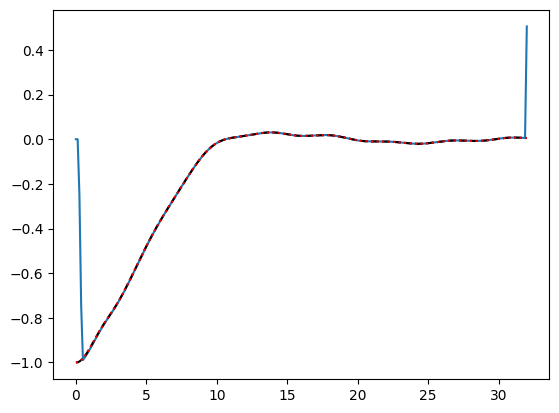

In [57]:
m, N, a, D = 0.5, 512, 0.125, 256
d = data[m, N, a, D]
#
# avarage over two bonds, can be done in 2 ways
#
plt.plot(d['time'], (d['Ln'][:, N // 2 + 1] + d['Ln'][:, N // 2 + 2]) / 2);
plt.plot(d['time'], d['pr2'] @ E2s, '--k');  # projectors on 2 bonds
plt.plot(d['time'], ((d['pr1b'] + d['pr1c']) / 2) @ E1s, ':r');  # projectors on 1 bond


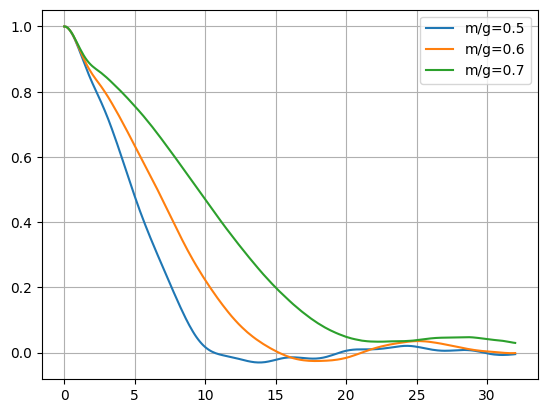

In [ ]:
# data from Fig 2a
N, a, D = 512, 0.125, 256
for m in [0.5, 0.6, 0.7]:
    d = data[m, N, a, D]
    time = d['time']
    Ln = ((d['pr1b'] + d['pr1c']) / 2) @ E1s

    plt.plot(time, -Ln, label=f"{m/g=:0.1f}")
    plt.grid()
    plt.legend()


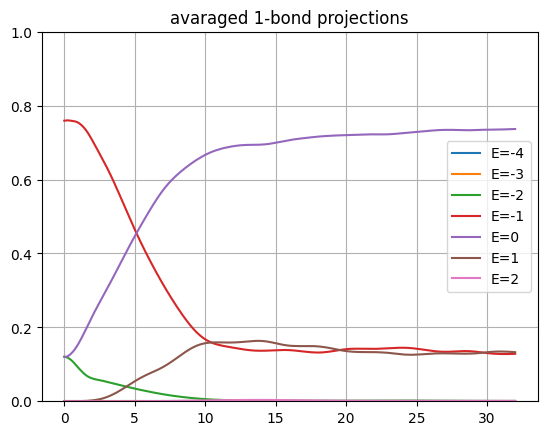

Text(0.5, 1.0, '2-bond projections')

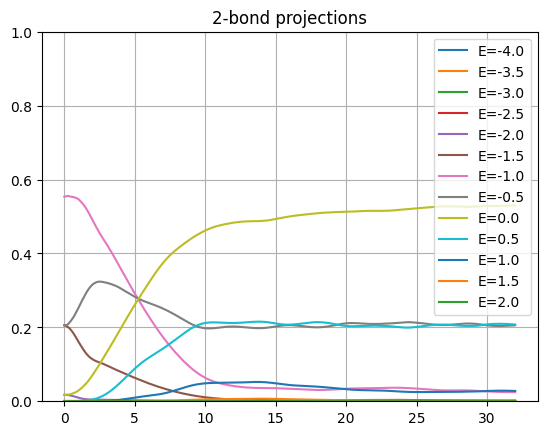

In [ ]:
# data from Fig 4

#  version with avaraged 1-bond projections
N, a, D = 512, 0.125, 256
m = 0.5

d = data[m, N, a, D]
time = d['time']
probs = ((d['pr1b'] + d['pr1c']) / 2)
for pr, E in zip(probs.transpose(), E1s):
    plt.plot(time, pr, label=f"{E=:1d}")
plt.grid()
plt.ylim([0, 1])
plt.legend()
plt.title('avaraged 1-bond projections')

plt.show()

time = d['time']
probs = d['pr2']
for pr, E in zip(probs.transpose(), E2s):
    plt.plot(time, pr, label=f"{E=:0.1f}")
plt.grid()
plt.ylim([0, 1])
plt.legend()
plt.title('2-bond projections')


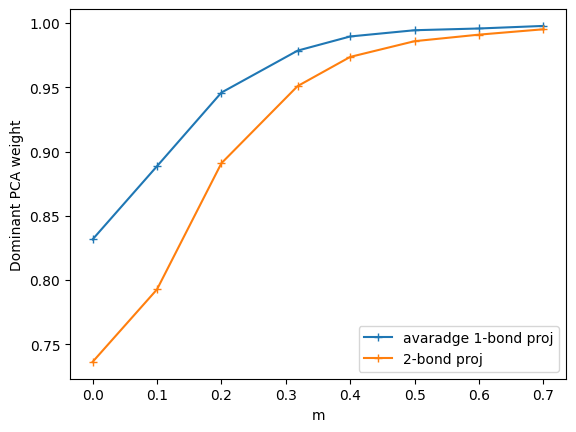

In [9]:
pca = PCA()

N, a, D = 512, 0.125, 256

dom = []
for m in ms:
    d = data[m, N, a, D]
    time = d['time']
    probs = ((d['pr1b'] + d['pr1c']) / 2)
    pca.fit(probs)
    y = pca.explained_variance_ratio_[0]
    dom.append(y)
plt.plot(ms, dom, '-+', label=f"avaradge 1-bond proj")

dom = []
for m in ms:
    d = data[m, N, a, D]
    time = d['time']
    probs = d['pr2']
    pca.fit(probs)
    y = pca.explained_variance_ratio_[0]
    dom.append(y)
plt.plot(ms, dom, '-+', label=f"2-bond proj")


plt.xlabel("m")
plt.ylabel("Dominant PCA weight")
plt.legend()

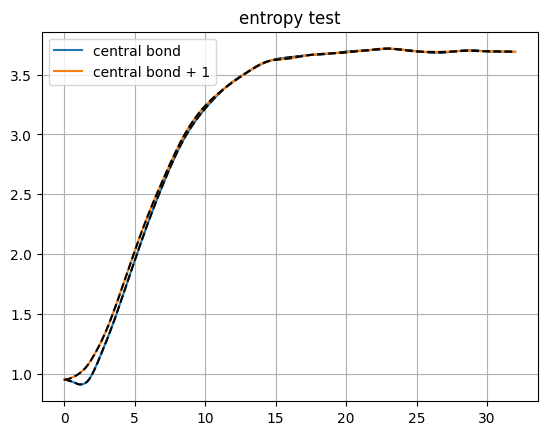

In [ ]:
# testing entropy formula

N, a, D = 512, 0.125, 256
m = 0.5

d = data[m, N, a, D]
time = d['time']

prob = d['pr1b']
ent = d['ent1b']
ent_total = d['entropy_1'][:, N // 2]
prob[prob < 1e-8] = 1e-8  # regularize small probabilities
ent_sum = np.sum(prob * ent, axis=1) - np.sum(prob * np.log2(prob), axis=1)
plt.plot(time, ent_total, label='central bond')
plt.plot(time, ent_sum, '--k')

prob = d['pr1c']
ent = d['ent1c']
ent_total = d['entropy_1'][:, N // 2 + 1]
prob[prob < 1e-8] = 1e-8  # regularize small probabilities
ent_sum = np.sum(prob * ent, axis=1) - np.sum(prob * np.log2(prob), axis=1)
plt.plot(time, ent_total, label='central bond + 1')
plt.plot(time, ent_sum, '--k')

plt.grid()
#plt.ylim([0, 1])
plt.legend()
plt.title('entropy test')
plt.show()